# EXP1

Dataset Loaded from Age_Fat.csv
Dataset Preview:
   Age  %Fat
0   23   7.8
1   23   9.5
2   27  17.8
3   27  25.9
4   39  26.5

Statistics for Numerical Column:
Mean: 28.783333333333328
Median: 30.7
Mode: 7.8
Standard Deviation: 9.2543948224296
Variance: 85.64382352941178
Range: 34.7


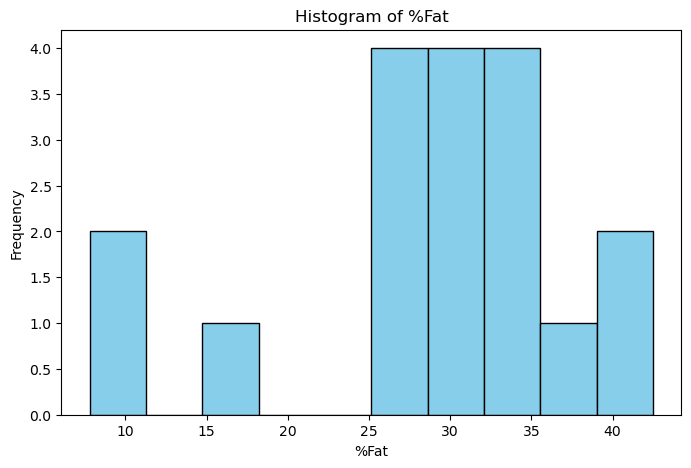

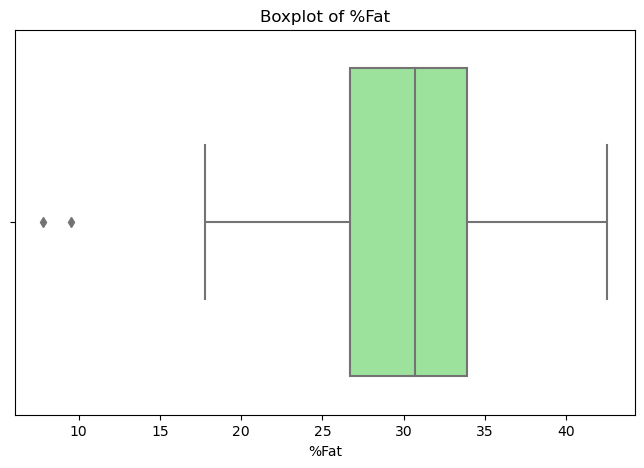


Outliers:
0    7.8
1    9.5
Name: %Fat, dtype: float64

Category Frequencies:
Older          9
Middle-aged    5
Young          4
Name: Age Group, dtype: int64


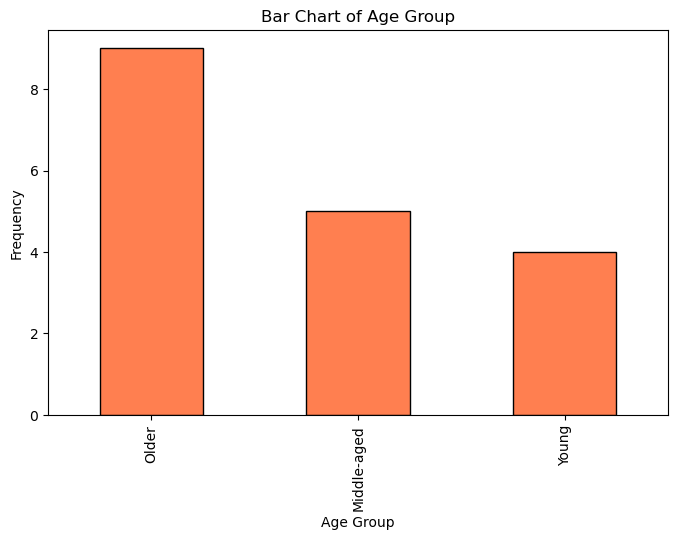

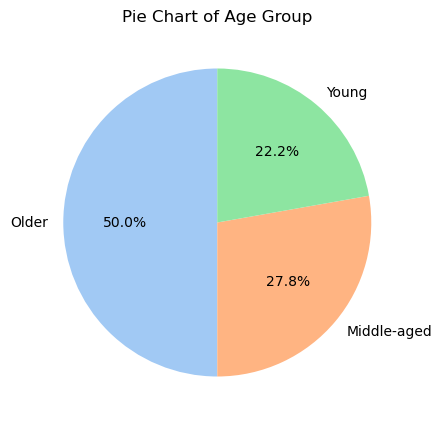

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.DataFrame({
'Age': [23, 23, 27, 27, 39, 41, 47, 49, 50, 52, 54, 54, 56, 57, 58, 58, 60, 61],
'%Fat': [7.8, 9.5, 17.8, 25.9, 26.5, 27.2, 27.4, 28.8, 30.2, 31.2, 31.4, 32.9, 33.4, 34.1,34.6, 35.7, 41.2, 42.5]})

data.to_csv('Age_Fat.csv', index=False)
print("Dataset Loaded from Age_Fat.csv")
data = pd.read_csv('Age_Fat.csv')

print("Dataset Preview:")
print(data.head())

numerical_column = '%Fat'
data_num = data[numerical_column]

mean_val = data_num.mean()
median_val = data_num.median()
mode_val = data_num.mode()[0]
std_dev = data_num.std()
variance = data_num.var()
range_val = data_num.max() - data_num.min()

print("\nStatistics for Numerical Column:")
print(f"Mean: {mean_val}")
print(f"Median: {median_val}")
print(f"Mode: {mode_val}")
print(f"Standard Deviation: {std_dev}")
print(f"Variance: {variance}")
print(f"Range: {range_val}")

plt.figure(figsize=(8, 5))
plt.hist(data_num, bins=10, color='skyblue', edgecolor='black')
plt.title(f"Histogram of {numerical_column}")
plt.xlabel(numerical_column)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=data_num, color='lightgreen')
plt.title(f"Boxplot of {numerical_column}")
plt.show()

q1 = data_num.quantile(0.25)
q3 = data_num.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = data_num[(data_num < lower_bound) | (data_num > upper_bound)]
print("\nOutliers:")
print(outliers)

def age_group(age):
    if age < 30:
        return 'Young'
    elif 30 <= age <= 50:
        return 'Middle-aged'
    else:
        return 'Older'
data['Age Group'] = data['Age'].apply(age_group)

categorical_column = 'Age Group'
data_cat = data[categorical_column]

category_counts = data_cat.value_counts()
print("\nCategory Frequencies:")
print(category_counts)

plt.figure(figsize=(8, 5))
category_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title(f"Bar Chart of {categorical_column}")
plt.xlabel(categorical_column)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
colors=sns.color_palette('pastel'))
plt.title(f"Pie Chart of {categorical_column}")
plt.ylabel("") 
plt.show()

# EXP2

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
file_path = 'iris.csv'
df = pd.read_csv(file_path)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
def inverse_square_weight(distances):
    return 1/(distances**2+1e-5)
def evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=False):
    results = {}
    for k in k_values:
        if weighted:
            knn = KNeighborsClassifier(n_neighbors=k, weights=inverse_square_weight)
        else:
            knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        conf_matrix = confusion_matrix(y_test, y_pred)
        results[k] = {'accuracy': accuracy,'f1_score': f1,'conf_matrix': conf_matrix}
    return results
k_values = [1, 3, 5]
regular_knn_results = evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=False)
print("Regular k-NN Results:")
for k, metrics in regular_knn_results.items():
    print(f"\nk={k}: Accuracy={metrics['accuracy']:.4f}, "f"F1-Score={metrics['f1_score']:.4f}")
    print("Confusion Matrix:")
    print(metrics['conf_matrix'])
weighted_knn_results = evaluate_knn(X_train, X_test, y_train, y_test, k_values, weighted=True)
print("\nWeighted k-NN Results (1/d^2):")
for k, metrics in weighted_knn_results.items():
    print(f"\nk={k}: Accuracy={metrics['accuracy']:.4f}, "f"F1-Score={metrics['f1_score']:.4f}")
    print("Confusion Matrix:")
    print(metrics['conf_matrix'])

Regular k-NN Results:

k=1: Accuracy=0.9778, F1-Score=0.9777
Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

k=3: Accuracy=1.0000, F1-Score=1.0000
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

k=5: Accuracy=1.0000, F1-Score=1.0000
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Weighted k-NN Results (1/d^2):

k=1: Accuracy=0.9778, F1-Score=0.9777
Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

k=3: Accuracy=1.0000, F1-Score=1.0000
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

k=5: Accuracy=1.0000, F1-Score=1.0000
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


# EXP3

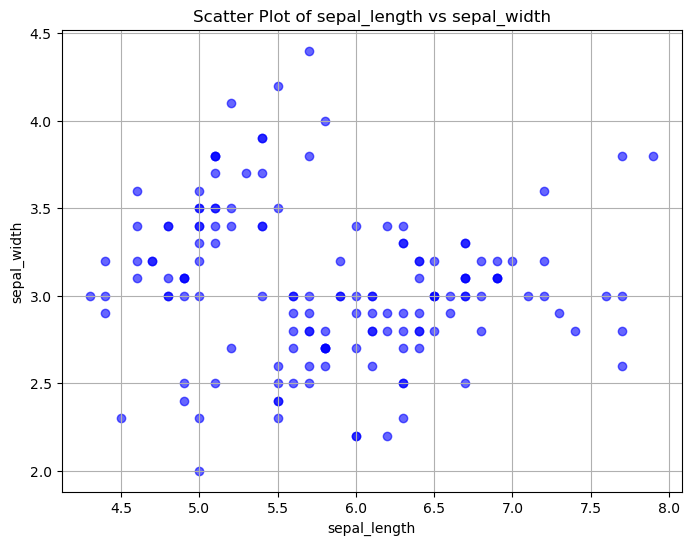

Pearson Correlation Coefficient (sepal_length vs sepal_width): -0.10936924995064937

Covariance Matrix:
[[ 0.68569351 -0.03926846]
 [-0.03926846  0.18800403]]

Correlation Matrix:
              sepal_length  sepal_width
sepal_length      1.000000    -0.109369
sepal_width      -0.109369     1.000000


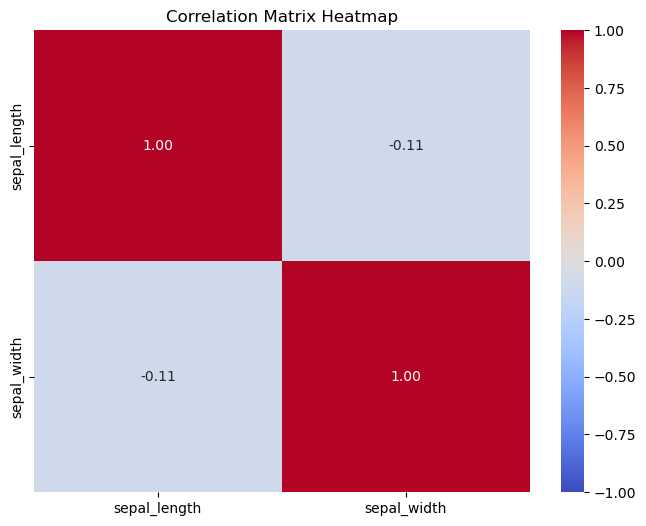

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path = "iris.csv"
df = pd.read_csv(file_path)
column1 = "sepal_length" 
column2 = "sepal_width"
selected_data = df[[column1, column2]]
plt.figure(figsize=(8, 6))
plt.scatter(selected_data[column1], selected_data[column2], color="blue", alpha=0.6)
plt.title(f"Scatter Plot of {column1} vs {column2}")
plt.xlabel(column1)
plt.ylabel(column2)
plt.grid(True)
plt.show()
correlation_coefficient = np.corrcoef(selected_data[column1], selected_data[column2])[0, 1]
print(f"Pearson Correlation Coefficient ({column1} vs {column2}): {correlation_coefficient}")
cov_matrix = np.cov(selected_data[column1], selected_data[column2])
print("\nCovariance Matrix:")
print(cov_matrix)
correlation_matrix = selected_data.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix,cmap="coolwarm",vmin=-1,vmax=1, annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

# EXP4


Dataset preview:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


Original dataset shape: (150, 4)
Reduced dataset shape: (150, 2)


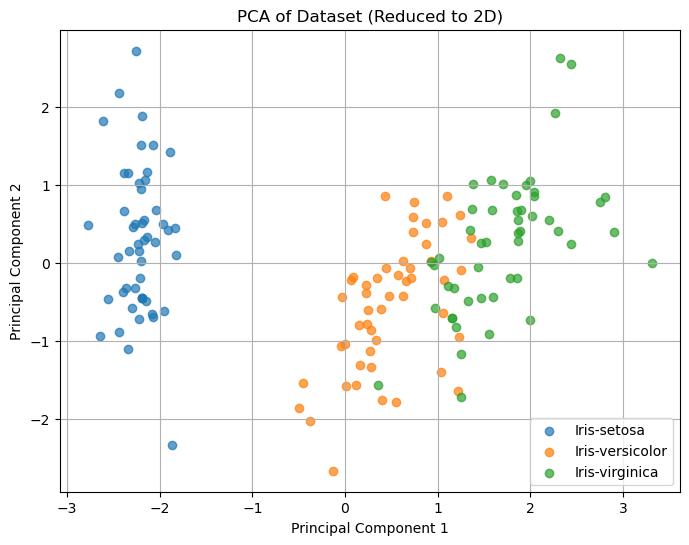

Explained variance ratio: [0.72770452 0.23030523]


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('iris.csv')
print("Dataset preview:")
print(df.head())
X = df.iloc[:, :-1].values 
y = df.iloc[:, -1].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
unique_labels = np.unique(y)
plt.figure(figsize=(8, 6))
for target in unique_labels:
    plt.scatter(X_pca[y == target, 0], X_pca[y == target, 1], label=target, alpha=0.7)
print("\n\nOriginal dataset shape:", X_scaled.shape) 
print("Reduced dataset shape:", X_pca.shape) 
plt.title('PCA of Dataset (Reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_)

# EXP5

Predicted Tip for a total bill of $30: 3.99


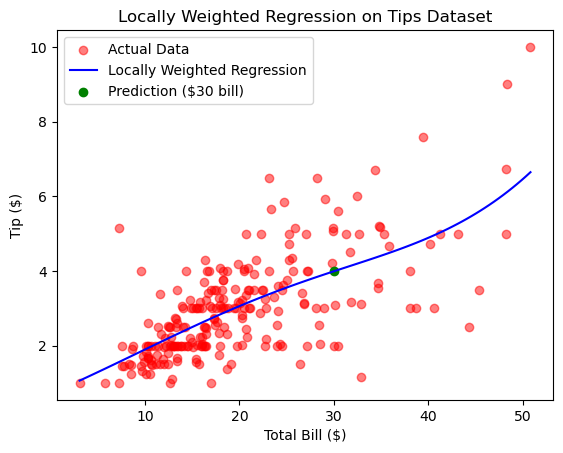

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "10-dataset.csv"  
tips = pd.read_csv(file_path)

X = tips["total_bill"].values
y = tips["tip"].values

def locally_weighted_regression(x_query, X, y, tau):
    m = len(X)
    weights = np.exp(-((X - x_query) ** 2) / (2 * tau ** 2))  
    
    X_b = np.c_[np.ones(m), X] 
    W = np.diag(weights)  
    
    theta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y)
    
    x_query_b = np.array([1, x_query])
    return x_query_b @ theta

tau = 10  
x_query = 30
predicted_tip = locally_weighted_regression(x_query, X, y, tau)
print(f"Predicted Tip for a total bill of $30: {predicted_tip:.2f}")

X_range = np.linspace(X.min(), X.max(), 100)
y_pred = np.array([locally_weighted_regression(x, X, y, tau) for x in X_range])

plt.scatter(X, y, color='red', alpha=0.5, label="Actual Data")
plt.plot(X_range, y_pred, color='blue', label="Locally Weighted Regression")
plt.scatter([x_query], [predicted_tip], color='green', marker='o', label="Prediction ($30 bill)")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend()
plt.title("Locally Weighted Regression on Tips Dataset")
plt.show()

# EXP6

## 1) Linear Regression

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [16]:
data = pd.read_csv("BostonHousing.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


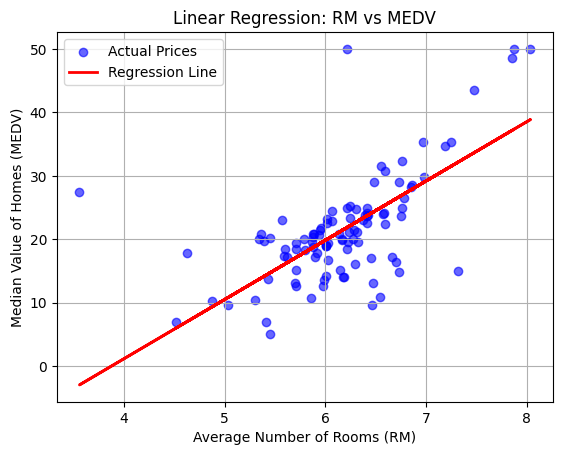

In [17]:
X = data[['rm']]      
y = data['medv']       

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, color='blue', label='Actual Prices', alpha = 0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median Value of Homes (MEDV)")
plt.title("Linear Regression: RM vs MEDV")
plt.legend()
plt.grid(True)
plt.show()

## 2) Polynomial regression

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [19]:
data = pd.read_csv("auto-mpg.csv") 
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


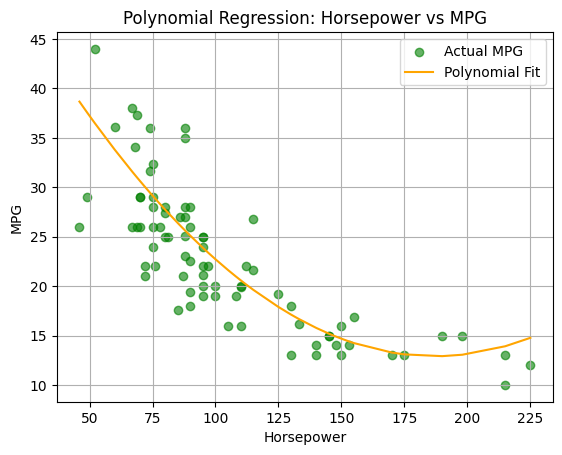

In [20]:
data.replace({'horsepower': {'?': np.nan}}, inplace=True)
data.dropna(subset=['horsepower'], inplace=True)
data['horsepower'] = data['horsepower'].astype(float)

X = data[['horsepower']]
y = data['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

plt.scatter(X_test, y_test, color='green', label='Actual MPG',alpha = 0.6)
sorted_idx = X_test['horsepower'].argsort()
plt.plot(X_test.iloc[sorted_idx], y_pred[sorted_idx], color='orange', label='Polynomial Fit')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression: Horsepower vs MPG")
plt.legend()
plt.grid(True)
plt.show()

# EXP7

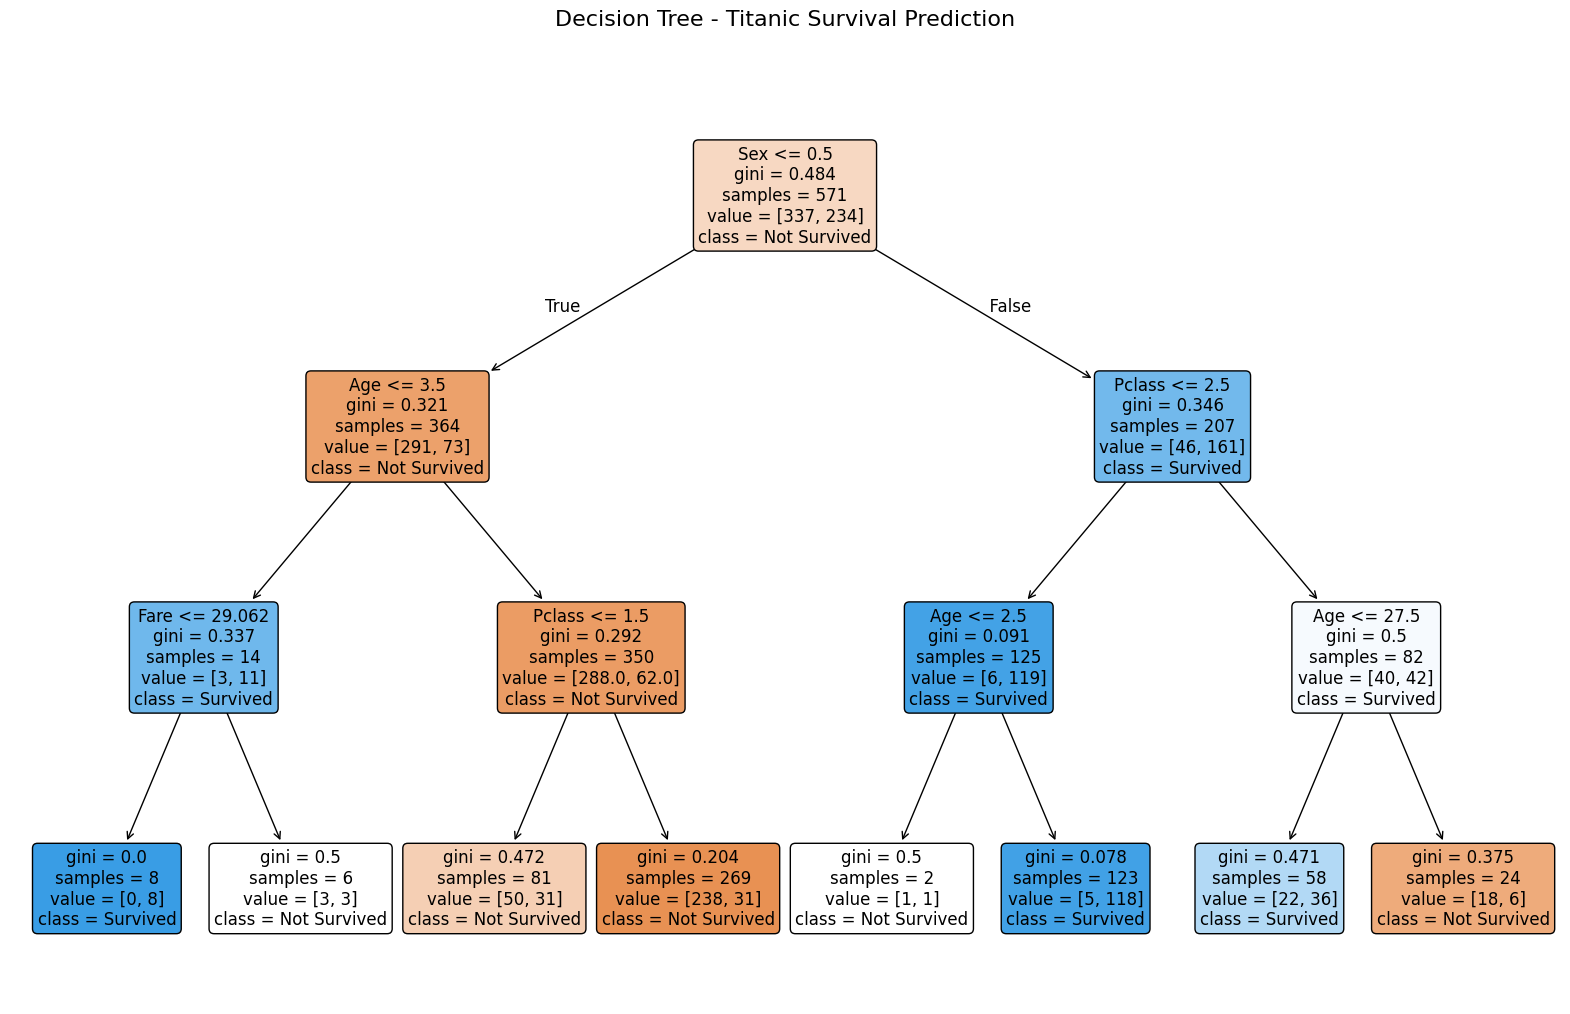

Accuracy: 0.7412587412587412
Precision: 0.6938775510204082
Recall: 0.6071428571428571
F1-score: 0.6476190476190476


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
file_path = 'titanic.csv'
df = pd.read_csv(file_path)
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df.dropna(subset=['Survived', 'Pclass', 'Sex', 'Age', 'Fare'], inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42, max_depth=3)
clf.fit(X_train, y_train)
plt.figure(figsize=(20, 12)) 
plot_tree(clf,feature_names=X.columns,class_names=["Not Survived", "Survived"],filled=True,rounded=True,fontsize=12)
plt.title("Decision Tree - Titanic Survival Prediction\n\n", fontsize=16)
plt.show()
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# EXP8

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
data = pd.read_csv('iris.csv')
X = data.iloc[:, :-1] 
y = data.iloc[:, -1] 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Naive Bayes Classifier: {accuracy * 100:.2f}%")

Accuracy of the Naive Bayes Classifier: 97.78%


# EXP9

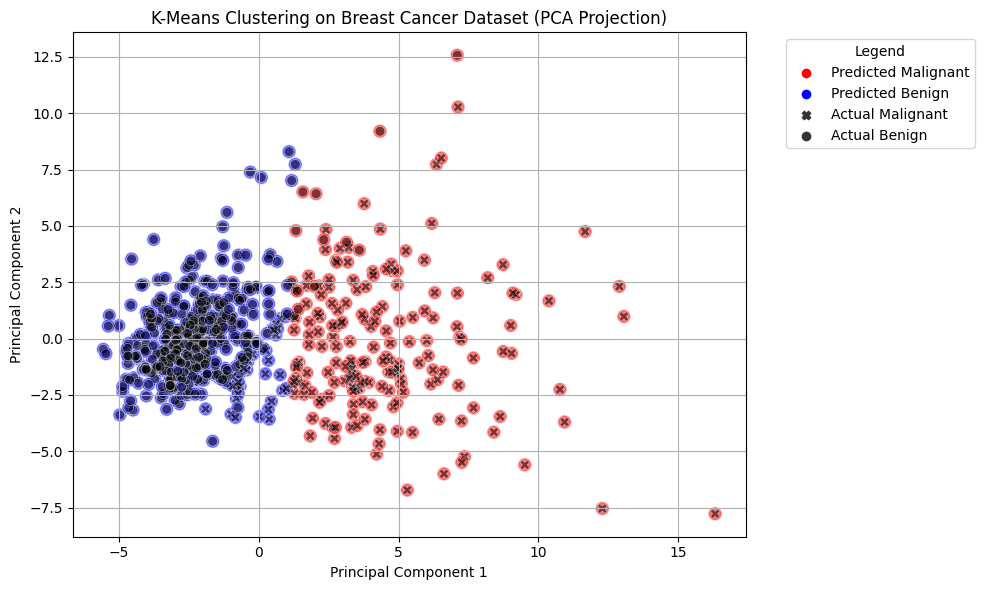

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mode
df = pd.read_csv("Breast Cancer Wisconsin.csv")
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
if 'diagnosis' in df.columns:
    diagnosis = df['diagnosis'].map({'M': 1, 'B': 0})  
    df = df.drop(columns=['diagnosis'])
else:
    diagnosis = None
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(scaled_data)
labels = kmeans.labels_
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
vis_df = pd.DataFrame({'PCA1': pca_data[:, 0],'PCA2': pca_data[:, 1],'Cluster': labels})
if diagnosis is not None:
    vis_df['Actual'] = diagnosis
    cluster_map = {}
    for cluster in [0, 1]:
        majority = mode(diagnosis[labels == cluster], keepdims=True).mode[0]
        cluster_map[cluster] = 'Predicted Malignant' if majority == 1 else 'Predicted Benign'
    vis_df['Cluster_Label'] = vis_df['Cluster'].map(cluster_map)
    vis_df['Actual_Label'] = vis_df['Actual'].map({1: 'Actual Malignant', 0: 'Actual Benign'})
plt.figure(figsize=(10, 6))
sns.scatterplot(data=vis_df,x='PCA1', y='PCA2',hue='Cluster_Label',palette={'Predicted Malignant': 'red', 'Predicted Benign': 'blue'},s=100,alpha=0.6,legend='full')
sns.scatterplot(data=vis_df,x='PCA1', y='PCA2',style='Actual_Label',markers={'Actual Malignant': 'X', 'Actual Benign': 'o'},color='black',s=50,alpha=0.5,legend='brief')
plt.title("K-Means Clustering on Breast Cancer Dataset (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Open Ended EXP 1

In [1]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ================================
# 2. Load Dataset
# ================================
# Make sure titanic.csv is in your working directory
df = pd.read_csv("titanic.csv")

# ================================
# 3. Data Preprocessing
# ================================

# Drop unnecessary columns
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical variables to numeric
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# ================================
# 4. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 5. Feature Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 6. Initialize Models
# ================================
lr = LogisticRegression()
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# ================================
# 7. Train Models
# ================================
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
knn.fit(X_train, y_train)

# ================================
# 8. Evaluation Function
# ================================
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name} Performance:")
    print("-" * 30)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return [acc, prec, rec, f1]

# ================================
# 9. Evaluate All Models
# ================================
lr_results = evaluate_model("Logistic Regression", lr, X_test, y_test)
dt_results = evaluate_model("Decision Tree", dt, X_test, y_test)
knn_results = evaluate_model("KNN", knn, X_test, y_test)

# ================================
# 10. Compare Results
# ================================
results_df = pd.DataFrame(
    [lr_results, dt_results, knn_results],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    index=['Logistic Regression', 'Decision Tree', 'KNN']
)

print("\nFinal Comparison:")
print("=" * 40)
print(results_df)

# ================================
# 11. Identify Best Model
# ================================
best_model = results_df['Accuracy'].idxmax()
print(f"\nBest Model based on Accuracy: {best_model}")


Logistic Regression Performance:
------------------------------
Accuracy  : 0.8045
Precision : 0.7746
Recall    : 0.7432
F1-score  : 0.7586

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179


Decision Tree Performance:
------------------------------
Accuracy  : 0.7207
Precision : 0.6579
Recall    : 0.6757
F1-score  : 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.75      0.76       105
           1       0.66      0.68      0.67        74

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179


KNN Performance:
----

/tmp/ipykernel_5334/3584290924.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_5334/3584290924.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 